In [1]:
import matplotlib.pyplot as plt
import seaborn as sea
from Bio.PDB.MMCIFParser import MMCIFParser
import numpy as np
import pathlib as Path
import pandas as pd

In [3]:
parser = MMCIFParser()

path = "/stor/home/sje779/Work/Clottein_folding/Datavis/structures_cif/Pro1668_wo_MBP-ligand_CYN/af3/seed-2/Pro1668_wo_MBP_seed-2_sample-0_model.cif"

with open(path, "r") as f:
    structure = parser.get_structure("Pro1668", f)
    print(structure)

FileNotFoundError: [Errno 2] No such file or directory: '/stor/home/sje779/Work/Clottein_folding/Datavis/structures_cif/Pro1668_wo_MBP-ligand_CYN/af3/seed-2/Pro1668_wo_MBP_seed-2_sample-0_model.cif'

In [13]:
residue_plddt = []

for models in structure:
    for chains in models:
        for residues in chains:
            atom_plddt = []
            for atom in residues:
                plddt = atom.get_bfactor()
                atom_plddt.append(float(plddt))
            residue_plddt.append(np.average(atom_plddt))
                  

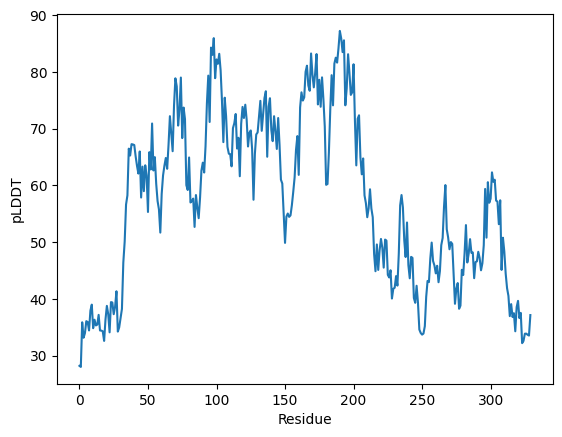

In [14]:
array = np.array(residue_plddt)
x = np.arange(len(array))
plt.plot(x, array)
plt.xlabel("Residue")
plt.ylabel("pLDDT")
plt.show()

In [46]:
print(f"Average pLDDT score: {np.average(residue_plddt)}")

Average pLDDT score: 62.12628735005174


In [9]:
parser = MMCIFParser()

directory_path = Path.Path("/stor/home/sje779/Work/Clottein_folding/Datavis/structures_cif/Pro1668_wo_MBP-ligand_CYN/chai1")

def get_structure(path: str) -> 'Bio.PDB.Structure':
    with open(path, "r") as f:
        structure = parser.get_structure("Pro1668", f)
        return structure
    
def get_plddt(structure: 'Bio.PDB.Structure') -> np.ndarray:
    residue_plddt = []

    for models in structure:
        for chains in models:
            for residues in chains:
                atom_plddt = []
                for atom in residues:
                    plddt = atom.get_bfactor()
                    atom_plddt.append(float(plddt))
                residue_plddt.append(np.average(atom_plddt))
    residue_plddt_array = np.array(residue_plddt)
    return residue_plddt_array

sample_plddts = []
counter = 0
include = [1, 6, 11, 16, 21]
for item in directory_path.iterdir():
    counter += 1
    if counter in include:
        print(item.name)
        if item.is_file():
            structure = get_structure(str(item))
            sample_plddts.append(get_plddt(structure))
sample_plddts_array = np.array(sample_plddts)
print(sample_plddts_array[0][5]) 


trunk0_4.cif
trunk3_2.cif
trunk4_0.cif
trunk4_3.cif
trunk1_0.cif
36.00575


In [10]:
df = pd.DataFrame(sample_plddts_array)
print(df.head())

         0          1          2          3          4          5        6    \
0  27.170625  27.845000  35.622786  32.527000  34.321167  36.005750  36.2460   
1  26.455000  28.024111  35.635429  32.809500  34.042500  36.183500  36.1068   
2  28.507625  28.796333  35.732429  32.890250  34.637667  35.907625  36.5758   
3  27.788250  27.485889  35.671071  32.336125  34.475667  35.388250  36.2712   
4  28.185125  27.993667  35.861286  33.135625  33.948000  36.060875  35.9172   

         7          8        9    ...       320        321       322  \
0  34.443000  37.993500  38.8462  ...  39.33050  39.141286  36.80275   
1  33.875625  36.925125  37.7512  ...  39.73700  39.414286  36.99275   
2  34.237125  37.726375  37.9084  ...  38.06125  36.857571  35.91875   
3  34.497875  36.934250  38.0652  ...  38.16850  36.303286  35.65475   
4  34.426375  37.925625  38.9746  ...  39.63850  36.602429  37.52200   

         323        324        325        326        327        328        329  
0  32

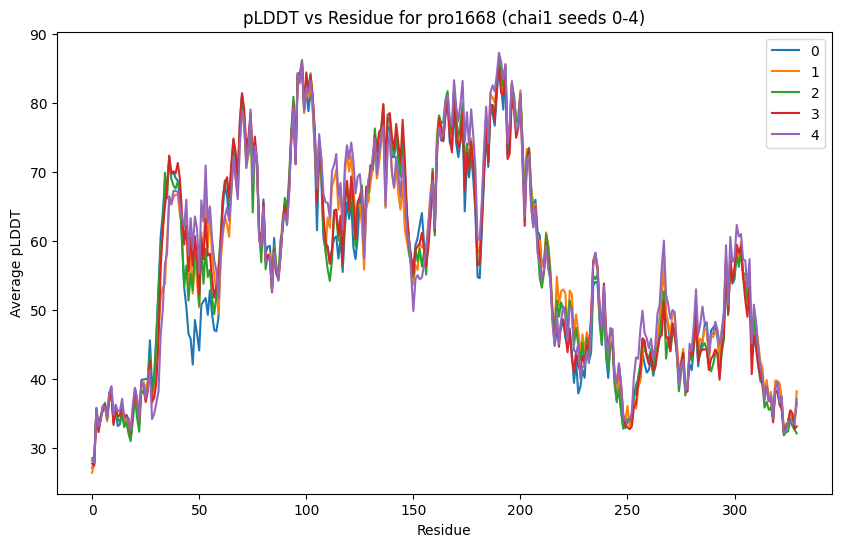

In [11]:
fig, ax = plt.subplots(figsize=(10,6))
df.T.plot(ax=ax)
ax.set_title("pLDDT vs Residue for pro1668 (chai1 seeds 0-4)")
ax.set_xlabel("Residue")
ax.set_ylabel("Average pLDDT")
plt.show()